In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Online Retail.xlsx")

print("Dataset loaded:", df.shape)

Dataset loaded: (541909, 8)


In [2]:
df = df.drop_duplicates()

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df = df.dropna(subset=["CustomerID"])

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned data:", df.shape)

Cleaned data: (392692, 9)


In [3]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [4]:
rfm.shape

(4338, 3)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

print("Data scaled successfully!")

Data scaled successfully!


In [6]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled)
    
    inertia.append(kmeans.inertia_)

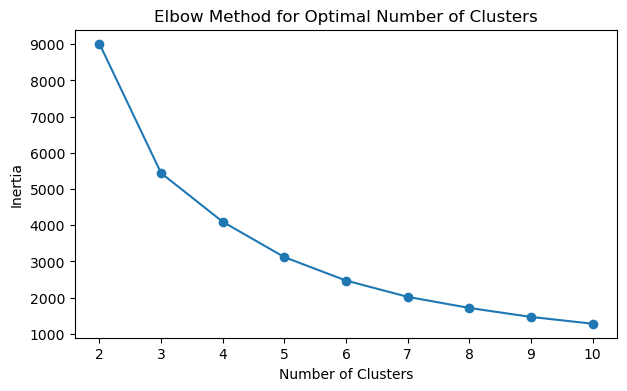

In [7]:
plt.figure(figsize=(7, 4))

plt.plot(range(2, 11), inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [9]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    3054
1    1067
2      13
3     204
Name: count, dtype: int64

In [10]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


In [11]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    rfm_scaled,
    rfm["Cluster"]
)

print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.6162


In [12]:
import joblib

joblib.dump(kmeans, "segmentation_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
